In [67]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
import pandas as pd

df = pd.read_excel("../data/Online_Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# Exploratory Data Analysis

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [23]:
# Generate descriptive statistics
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [24]:
# Count missing values for each column
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

# Data Cleaning

## Check Duplicates

In [25]:
# Check duplicate rows
df.duplicated().sum()

np.int64(5268)

In [27]:
# Remove duplicate rows
df = df.drop_duplicates()

In [28]:
df.shape

(536641, 8)

In [29]:
# Remove duplicate rows
df = df.drop_duplicates()

## Remove Missing CustomerID

In [30]:
# Remove rows with missing CustomerID
df = df.dropna(subset=["CustomerID"])

## Remove Negative Quantity and  Invalid Prices

In [32]:
# Remove rows with negative or zero quantity
df = df[df["Quantity"] > 0]

# Remove rows with negative or zero prices
df = df[df["UnitPrice"] > 0]

In [35]:
# Check dataset shape after cleaning
df.shape


(392692, 8)

In [37]:
# Check remaining missing values
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

# Feature Engineering (ETL)

## Total Price

In [38]:
# Create total revenue per transaction line
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

## Time Features

In [40]:
# Ensure InvoiceDate is datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Extract time-based features
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day
df["Hour"] = df["InvoiceDate"].dt.hour

In [41]:
# Save processed dataset
df.to_csv("../data/processed/cleaned_data.csv", index=False)

In [42]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,2011,12,9,12
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,2011,12,9,12
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011,12,9,12
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011,12,9,12


# Data Modeling

## Customer Dataset

In [43]:
# Group data by CustomerID
# we want one row per customer
customer_df = df.groupby("CustomerID").agg({
    "InvoiceNo": "nunique",      # number of transactions
    "TotalPrice": "sum",         # total money spent
    "InvoiceDate": "max"         # last purchase date
}).reset_index()


In [44]:
# Rename columns for clarity
customer_df.columns = ["CustomerID", "Frequency", "Monetary", "LastPurchaseDate"]

In [45]:
# Get the latest date in dataset
reference_date = df["InvoiceDate"].max()

# Calculate recency (days since last purchase)
customer_df["Recency"] = (reference_date - customer_df["LastPurchaseDate"]).dt.days

In [46]:
# Save customer dataset
customer_df.to_csv("../data/processed/customers.csv", index=False)

In [47]:
# Save customer dataset
customer_df

,CustomerID,Frequency,Monetary,LastPurchaseDate,Recency
0,12346.0,1,77183.60,2011-01-18 10:01:00,325
1,12347.0,7,4310.00,2011-12-07 15:52:00,1
2,12348.0,4,1797.24,2011-09-25 13:13:00,74
3,12349.0,1,1757.55,2011-11-21 09:51:00,18
4,12350.0,1,334.40,2011-02-02 16:01:00,309
...,...,...,...,...,...
4333,18280.0,1,180.60,2011-03-07 09:52:00,277
4334,18281.0,1,80.82,2011-06-12 10:53:00,180
4335,18282.0,2,178.05,2011-12-02 11:43:00,7
4336,18283.0,16,2045.53,2011-12-06 12:02:00,3


# Customer Analysis

In [48]:
customer_df.head()

,CustomerID,Frequency,Monetary,LastPurchaseDate,Recency
0,12346.0,1,77183.60,2011-01-18 10:01:00,325
1,12347.0,7,4310.00,2011-12-07 15:52:00,1
2,12348.0,4,1797.24,2011-09-25 13:13:00,74
3,12349.0,1,1757.55,2011-11-21 09:51:00,18
4,12350.0,1,334.40,2011-02-02 16:01:00,309


In [49]:
customer_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CustomerID        4338 non-null   float64       
 1   Frequency         4338 non-null   int64         
 2   Monetary          4338 non-null   float64       
 3   LastPurchaseDate  4338 non-null   datetime64[us]
 4   Recency           4338 non-null   int64         
dtypes: datetime64[us](1), float64(2), int64(2)
memory usage: 169.6 KB


In [50]:
# Generate descriptive statistics
customer_df.describe()

,CustomerID,Frequency,Monetary,LastPurchaseDate,Recency
count,4338.000000,4338.000000,4338.000000,4338,4338.000000
mean,15300.408022,4.272015,2048.688081,2011-09-08 11:38:59.045643,91.536422
min,12346.000000,1.000000,3.750000,2010-12-01 09:53:00,0.000000
25%,13813.250000,1.000000,306.482500,2011-07-20 19:18:00,17.000000
50%,15299.500000,2.000000,668.570000,2011-10-20 10:40:30,50.000000
75%,16778.750000,5.000000,1660.597500,2011-11-22 11:05:45,141.000000
max,18287.000000,209.000000,280206.020000,2011-12-09 12:50:00,373.000000
std,1721.808492,7.697998,8985.230220,NaN,100.014169


In [51]:
# Check missing values in the customer dataset
customer_df.isnull().sum()

CustomerID          0
Frequency           0
Monetary            0
LastPurchaseDate    0
Recency             0
dtype: int64

In [52]:
# Display top customers by revenue
customer_df.sort_values(by="Monetary", ascending=False).head(10)

,CustomerID,Frequency,Monetary,LastPurchaseDate,Recency
1689,14646.0,73,280206.02,2011-12-08 12:12:00,1
4201,18102.0,60,259657.30,2011-12-09 11:50:00,0
3728,17450.0,46,194390.79,2011-12-01 13:29:00,7
3008,16446.0,2,168472.50,2011-12-09 09:15:00,0
1879,14911.0,201,143711.17,2011-12-08 15:54:00,0
55,12415.0,21,124914.53,2011-11-15 14:22:00,23
1333,14156.0,55,117210.08,2011-11-30 10:54:00,9
3771,17511.0,31,91062.38,2011-12-07 10:12:00,2
2702,16029.0,63,80850.84,2011-11-01 10:27:00,38
0,12346.0,1,77183.60,2011-01-18 10:01:00,325


In [54]:
# Display most frequent customers
customer_df.sort_values(by="Frequency", ascending=False).head(10)

,CustomerID,Frequency,Monetary,LastPurchaseDate,Recency
326,12748.0,209,33053.19,2011-12-09 12:20:00,0
1879,14911.0,201,143711.17,2011-12-08 15:54:00,0
4010,17841.0,124,40519.84,2011-12-08 12:07:00,1
562,13089.0,97,58762.08,2011-12-07 09:02:00,2
1661,14606.0,93,12076.15,2011-12-08 19:28:00,0
2176,15311.0,91,60632.75,2011-12-09 12:00:00,0
481,12971.0,86,11189.91,2011-12-06 12:20:00,3
1689,14646.0,73,280206.02,2011-12-08 12:12:00,1
2702,16029.0,63,80850.84,2011-11-01 10:27:00,38
795,13408.0,62,28117.04,2011-12-08 09:05:00,1


# Customer Segmentation (RFM Segmentation)

In [55]:
# Create R score based on Recency
customer_df["R_score"] = pd.qcut(
    customer_df["Recency"],
    q=4,
    labels=[4, 3, 2, 1]
)

In [56]:
# Create F score based on Frequency
customer_df["F_score"] = pd.qcut(
    customer_df["Frequency"].rank(method="first"),
    q=4,
    labels=[1, 2, 3, 4]
)

In [57]:
# Create M score based on Monetary
customer_df["M_score"] = pd.qcut(
    customer_df["Monetary"],
    q=4,
    labels=[1, 2, 3, 4]
)

In [58]:
customer_df

,CustomerID,Frequency,Monetary,LastPurchaseDate,Recency,R_score,F_score,M_score
0,12346.0,1,77183.60,2011-01-18 10:01:00,325,1,1,4
1,12347.0,7,4310.00,2011-12-07 15:52:00,1,4,4,4
2,12348.0,4,1797.24,2011-09-25 13:13:00,74,2,3,4
3,12349.0,1,1757.55,2011-11-21 09:51:00,18,3,1,4
4,12350.0,1,334.40,2011-02-02 16:01:00,309,1,1,2
...,...,...,...,...,...,...,...,...
4333,18280.0,1,180.60,2011-03-07 09:52:00,277,1,2,1
4334,18281.0,1,80.82,2011-06-12 10:53:00,180,1,2,1
4335,18282.0,2,178.05,2011-12-02 11:43:00,7,4,3,1
4336,18283.0,16,2045.53,2011-12-06 12:02:00,3,4,4,4


In [59]:
# Convert scores to integer
customer_df["R_score"] = customer_df["R_score"].astype(int)
customer_df["F_score"] = customer_df["F_score"].astype(int)
customer_df["M_score"] = customer_df["M_score"].astype(int)

In [60]:
# Create total RFM score
customer_df["RFM_Score"] = (
    customer_df["R_score"] +
    customer_df["F_score"] +
    customer_df["M_score"]
)

In [61]:
customer_df

,CustomerID,Frequency,Monetary,LastPurchaseDate,Recency,R_score,F_score,M_score,RFM_Score
0,12346.0,1,77183.60,2011-01-18 10:01:00,325,1,1,4,6
1,12347.0,7,4310.00,2011-12-07 15:52:00,1,4,4,4,12
2,12348.0,4,1797.24,2011-09-25 13:13:00,74,2,3,4,9
3,12349.0,1,1757.55,2011-11-21 09:51:00,18,3,1,4,8
4,12350.0,1,334.40,2011-02-02 16:01:00,309,1,1,2,4
...,...,...,...,...,...,...,...,...,...
4333,18280.0,1,180.60,2011-03-07 09:52:00,277,1,2,1,4
4334,18281.0,1,80.82,2011-06-12 10:53:00,180,1,2,1,4
4335,18282.0,2,178.05,2011-12-02 11:43:00,7,4,3,1,8
4336,18283.0,16,2045.53,2011-12-06 12:02:00,3,4,4,4,12


In [63]:
# Create customer segments based on RFM score
def segment_customer(score):
    if score >= 10:
        return "VIP Customer"
    elif score >= 7:
        return "Loyal Customer"
    elif score >= 5:
        return "At Risk Customer"
    else:
        return "Lost Customer"

In [64]:
# Apply segmentation function to each customer
customer_df["CustomerSegment"] = customer_df["RFM_Score"].apply(segment_customer)

In [65]:
# Count customers in each segment
customer_df["CustomerSegment"].value_counts()

CustomerSegment
Loyal Customer      1276
VIP Customer        1267
At Risk Customer     989
Lost Customer        806
Name: count, dtype: int64

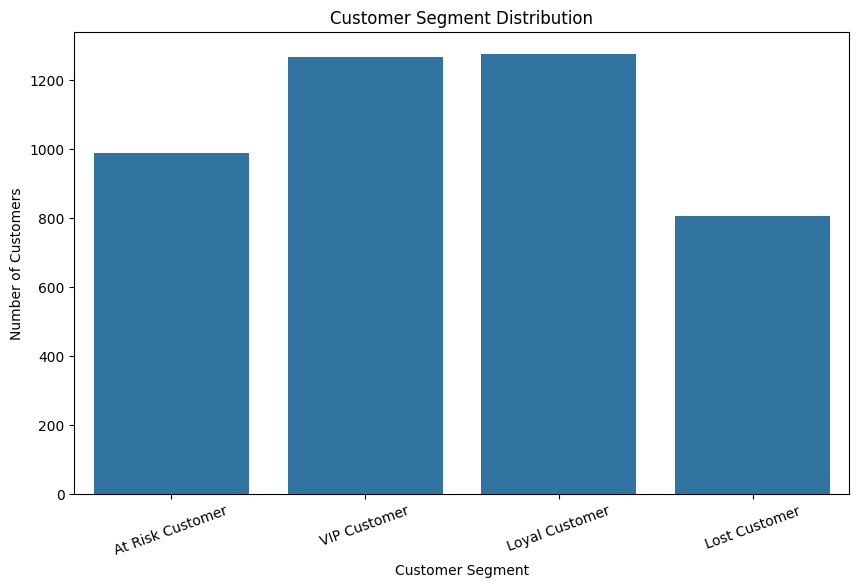

In [68]:
# Plot customer segment distribution
plt.figure(figsize=(10, 6))

sns.countplot(
    data=customer_df,
    x="CustomerSegment"
)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)

plt.show()

### Analysis of Customer Segment Distribution

The visualization shows a strong proportion of VIP Customers and Loyal Customers, indicating that a large part of the customer base is active, engaged, and generates significant revenue. This is a positive sign for business stability and customer retention.

The presence of At Risk Customers highlights an important opportunity for targeted retention strategies such as personalized promotions, loyalty campaigns, or re-engagement actions to prevent potential churn.

The lower number of Lost Customers suggests that customer attrition remains relatively limited, which reflects a healthy customer relationship management process.

Overall, the RFM segmentation provides valuable business insights and helps prioritize marketing actions based on customer value and risk level.

In [69]:
# Save
customer_df.to_csv(
    "../data/processed/customers_segmented.csv",
    index=False
)

In [70]:
# Save final transactional dataset
# will be used as the sales fact table in SQL
df.to_csv("../data/processed/fact_sales.csv", index=False)

In [71]:
# Save final customer dataset with segmentation
# will be used as the customer dimension table in SQL
customer_df.to_csv("../data/processed/dim_customer.csv", index=False)

# SQL Database Creation

In [72]:
# Import SQLite library
import sqlite3

In [73]:
# Create a connection to the SQLite database
conn = sqlite3.connect("../data/processed/retail_analytics.db")

In [74]:
# Load sales data into SQL database
# creates the FactSales table from the dataframe
df.to_sql(
    "FactSales",
    conn,
    if_exists="replace",
    index=False
)

392692

In [75]:
# Load customer data into SQL database
# creates the DimCustomer table from the dataframe
customer_df.to_sql(
    "DimCustomer",
    conn,
    if_exists="replace",
    index=False
)

4338

In [76]:
# verify that FactSales and DimCustomer exist
pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

,name
0,FactSales
1,DimCustomer


In [ ]:
# Top Customers by Revenue

In [77]:
# Top customers by total spending
# identify the most valuable customers
pd.read_sql_query("""
    SELECT
        CustomerID,
        Monetary,
        CustomerSegment
    FROM DimCustomer
    ORDER BY Monetary DESC
    LIMIT 10;
""", conn)

,CustomerID,Monetary,CustomerSegment
0,14646.0,280206.02,VIP Customer
1,18102.0,259657.30,VIP Customer
2,17450.0,194390.79,VIP Customer
3,16446.0,168472.50,VIP Customer
4,14911.0,143711.17,VIP Customer
5,12415.0,124914.53,VIP Customer
6,14156.0,117210.08,VIP Customer
7,17511.0,91062.38,VIP Customer
8,16029.0,80850.84,VIP Customer
9,12346.0,77183.60,At Risk Customer


## A high-spending customer can still be at risk if they have not purchased recently

# Revenue by country

In [79]:

#identify top-performing markets
pd.read_sql_query("""
    SELECT
        Country,
        SUM(TotalPrice) AS TotalRevenue
    FROM FactSales
    GROUP BY Country
    ORDER BY TotalRevenue DESC;
""", conn)

,Country,TotalRevenue
0,United Kingdom,7285024.644
1,Netherlands,285446.340
2,EIRE,265262.460
3,Germany,228678.400
4,France,208934.310
5,Australia,138453.810
6,Spain,61558.560
7,Switzerland,56443.950
8,Belgium,41196.340
9,Sweden,38367.830


# Number of customers by segment

In [80]:
# -> business overview of customer base
pd.read_sql_query("""
    SELECT
        CustomerSegment,
        COUNT(*) AS NumberOfCustomers
    FROM DimCustomer
    GROUP BY CustomerSegment
    ORDER BY NumberOfCustomers DESC;
""", conn)

,CustomerSegment,NumberOfCustomers
0,Loyal Customer,1276
1,VIP Customer,1267
2,At Risk Customer,989
3,Lost Customer,806


In [100]:
# Create product dimension table
dim_product = df.groupby("StockCode").agg({
    "Description": "first",
    "UnitPrice": "mean"
}).reset_index()

In [101]:
# Display product table
dim_product.head()

,StockCode,Description,UnitPrice
0,10002,INFLATABLE POLITICAL GLOBE,0.850000
1,10080,GROOVY CACTUS INFLATABLE,0.411905
2,10120,DOGGY RUBBER,0.210000
3,10125,MINI FUNKY DESIGN TAPES,0.781746
4,10133,COLOURING PENCILS BROWN TUBE,0.529262


In [102]:
# Save date dimension table
dim_product.to_csv(
    "../data/processed/dim_product.csv",
    index=False
)

In [83]:
# Create date dimension table
dim_date = df[
    [
        "InvoiceDate",
        "Year",
        "Month",
        "Day",
        "Hour"
    ]
].drop_duplicates()

In [84]:
# Display date table
dim_date.head()

,InvoiceDate,Year,Month,Day,Hour
0,2010-12-01 08:26:00,2010,12,1,8
7,2010-12-01 08:28:00,2010,12,1,8
9,2010-12-01 08:34:00,2010,12,1,8
25,2010-12-01 08:35:00,2010,12,1,8
26,2010-12-01 08:45:00,2010,12,1,8


In [85]:
# Save date dimension table
dim_date.to_csv(
    "../data/processed/dim_date.csv",
    index=False
)

In [86]:
# Load product dimension into SQL database
dim_product.to_sql(
    "DimProduct",
    conn,
    if_exists="replace",
    index=False
)

8881

In [87]:
# Load date dimension into SQL database
dim_date.to_sql(
    "DimDate",
    conn,
    if_exists="replace",
    index=False
)

17282

In [88]:
# Verify all tables created in the database
pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

,name
0,FactSales
1,DimCustomer
2,DimProduct
3,DimDate


# Top products by revenue

In [ ]:
# Identify best-selling products 
pd.read_sql_query("""
    SELECT
        p.StockCode,
        p.Description,
        SUM(f.TotalPrice) AS TotalRevenue
    FROM FactSales f
    JOIN DimProduct p
        ON f.StockCode = p.StockCode
    GROUP BY
        p.StockCode,
        p.Description
    ORDER BY TotalRevenue DESC
    LIMIT 10;
""", conn)

,StockCode,Description,TotalRevenue
0,M,Manual,5609092.65
1,POST,POSTAGE,2489726.72
2,22423,REGENCY CAKESTAND 3 TIER,711323.75
3,85099B,JUMBO BAG RED RETROSPOT,680324.32
4,85123A,WHITE HANGING HEART T-LIGHT HOLDER,603284.70
5,47566,PARTY BUNTING,412711.38
6,79321,CHILLI LIGHTS,370120.88
7,82484,WOOD BLACK BOARD ANT WHITE FINISH,344147.10
8,22386,JUMBO BAG PINK POLKADOT,260780.52
9,21175,GIN + TONIC DIET METAL SIGN,260633.40


# Revenue by customer segment

In [90]:
# -> compare customer value across segments
pd.read_sql_query("""
    SELECT
        c.CustomerSegment,
        SUM(f.TotalPrice) AS TotalRevenue
    FROM FactSales f
    JOIN DimCustomer c
        ON f.CustomerID = c.CustomerID
    GROUP BY
        c.CustomerSegment
    ORDER BY TotalRevenue DESC;
""", conn)

,CustomerSegment,TotalRevenue
0,VIP Customer,6827235.770
1,Loyal Customer,1369352.353
2,At Risk Customer,512069.511
3,Lost Customer,178551.260


# Monthly revenue trend

In [91]:
# analyze how revenue evolves over time
pd.read_sql_query("""
    SELECT
        Year,
        Month,
        SUM(TotalPrice) AS TotalRevenue
    FROM FactSales
    GROUP BY
        Year,
        Month
    ORDER BY
        Year,
        Month;
""", conn)

,Year,Month,TotalRevenue
0,2010,12,570422.730
1,2011,1,568101.310
2,2011,2,446084.920
3,2011,3,594081.760
4,2011,4,468374.331
5,2011,5,677355.150
6,2011,6,660046.050
7,2011,7,598962.901
8,2011,8,644051.040
9,2011,9,950690.202


In [92]:
# Close the database connection
conn.close()